In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print(pd.__version__)


3.0.5


In [27]:
import os

print("Carpeta actual:")
print(os.getcwd())

print("\nArchivos y carpetas:")
print(os.listdir())

Carpeta actual:
C:\Users\marti\OneDrive\Escritorio\Repo\notebooks

Archivos y carpetas:
['.ipynb_checkpoints', 'analisis_accidentes.ipynb']


In [32]:
df = pd.read_csv("C:/Users/marti/OneDrive/Escritorio/Repo/data/acc.csv")
df.head()

,Año,Tipo de Vehículo,Siniestros,Fallecidos,Graves,Menos graves,Leves
0,2002,Automóvil,24511,266,1654,1900,11385
1,2002,Bicicleta,4192,175,800,670,2425
2,2002,Bus / Taxibus,8614,60,599,770,4660
3,2002,Camión,3473,73,304,219,881
4,2002,Camioneta,8125,130,735,735,3365


In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 293 entries, 0 to 292
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Año               293 non-null    int64
 1   Tipo de Vehículo  293 non-null    str  
 2   Siniestros        293 non-null    int64
 3   Fallecidos        293 non-null    int64
 4   Graves            293 non-null    int64
 5   Menos graves      293 non-null    int64
 6   Leves             293 non-null    int64
dtypes: int64(6), str(1)
memory usage: 16.2 KB


In [34]:
df.describe()

,Año,Siniestros,Fallecidos,Graves,Menos graves,Leves
count,293.000000,293.000000,293.000000,293.000000,293.000000,293.000000
mean,2013.689420,8205.112628,131.709898,605.648464,358.010239,3288.563140
std,7.024111,12632.613987,179.252943,703.245000,430.146100,4742.501303
min,2002.000000,23.000000,0.000000,1.000000,0.000000,6.000000
25%,2008.000000,1815.000000,19.000000,99.000000,63.000000,736.000000
50%,2014.000000,4094.000000,55.000000,248.000000,176.000000,1518.000000
75%,2020.000000,7894.000000,148.000000,735.000000,516.000000,3970.000000
max,2025.000000,67386.000000,817.000000,2721.000000,1900.000000,23011.000000


In [35]:
df.columns

Index(['Año', 'Tipo de Vehículo', 'Siniestros', 'Fallecidos', 'Graves',
       'Menos graves', 'Leves'],
      dtype='str')

In [38]:
df.isnull().sum()

Año                 0
Tipo de Vehículo    0
Siniestros          0
Fallecidos          0
Graves              0
Menos graves        0
Leves               0
dtype: int64

In [44]:
type(df.head())

pandas.DataFrame

In [100]:
siniestros_por_vehiculo = (
    df.groupby("Tipo de Vehículo")[["Siniestros", "Fallecidos"]]
      .sum()
        
)
print(siniestros_por_vehiculo)

                            Siniestros  Fallecidos
Tipo de Vehículo                                  
Automóvil                      1107574        9895
Bicicleta                        90142        2764
Bus / Taxibus                   166301        1029
Camioneta                       339438        3524
Camión                          128003        2015
Dado a la fuga                   16721          13
Furgón                           96484         780
Jeep                             75799         647
Minibus                          25988         223
Motocicleta                     119821        3140
Otros                            34483         562
Patín motorizado (Scooter)         353           1
Peatón                          202645       13991
Se ignora                          208           3
Triciclo                           138           4


In [70]:
df.groupby("Tipo de Vehículo")

In [74]:
df.groupby("Tipo de Vehículo").sum()

,Año,Siniestros,Fallecidos,Graves,Menos graves,Leves
Tipo de Vehículo,,,,,,
Automóvil,48324,1107574,9895,47597,36535,426444
Bicicleta,48324,90142,2764,14425,8169,56562
Bus / Taxibus,48324,166301,1029,8845,7458,81249
Camioneta,48324,339438,3524,16529,12136,111842
Camión,48324,128003,2015,5387,3573,24997
Dado a la fuga,48324,16721,13,150,90,780
Furgón,48324,96484,780,4113,3206,34233
Jeep,48324,75799,647,3289,2230,24816
Minibus,48324,25988,223,1452,1079,13830


In [72]:
df.groupby("Tipo de Vehículo")["Siniestros"].sum()

Tipo de Vehículo
Automóvil                     1107574
Bicicleta                       90142
Bus / Taxibus                  166301
Camioneta                      339438
Camión                         128003
Dado a la fuga                  16721
Furgón                          96484
Jeep                            75799
Minibus                         25988
Motocicleta                    119821
Otros                           34483
Patín motorizado (Scooter)        353
Peatón                         202645
Se ignora                         208
Triciclo                          138
Name: Siniestros, dtype: int64

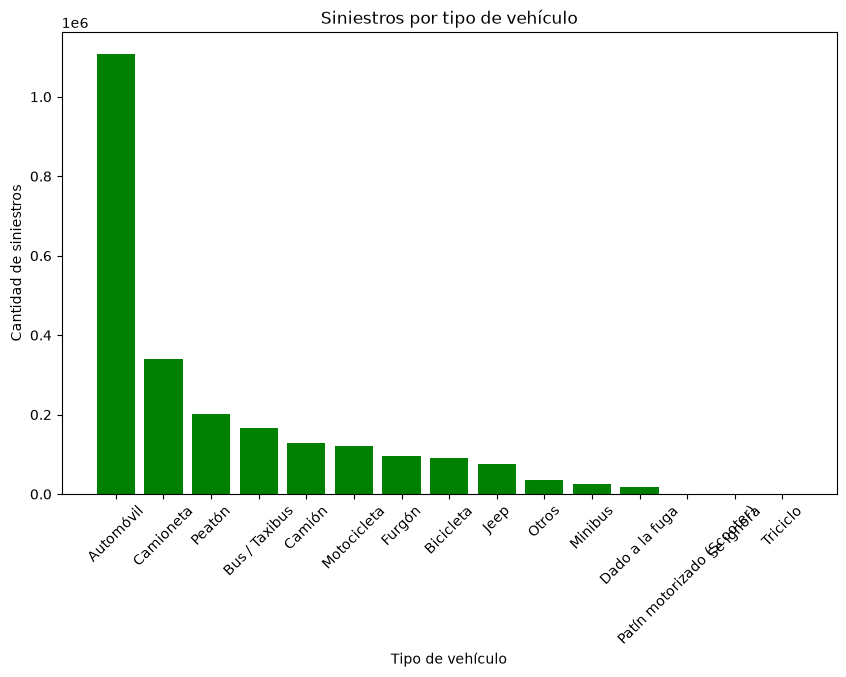

In [88]:
plt.figure(figsize=(10,6))

plt.bar(
    siniestros_por_vehiculo.index,
    siniestros_por_vehiculo.values,
    color="green"
)

plt.title("Siniestros por tipo de vehículo")
plt.xlabel("Tipo de vehículo")
plt.ylabel("Cantidad de siniestros")

plt.xticks(rotation=45)

plt.show()

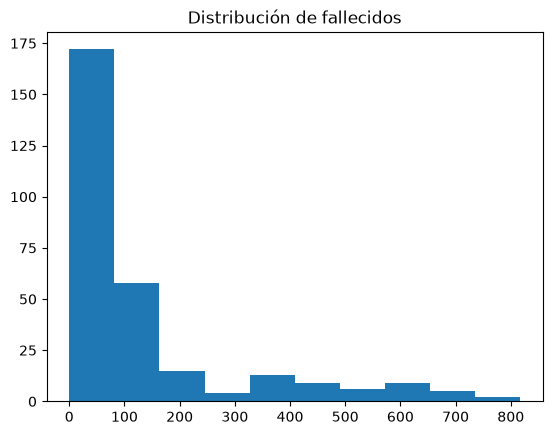

In [93]:
plt.hist(df["Fallecidos"])

plt.title("Distribución de fallecidos")

plt.show()

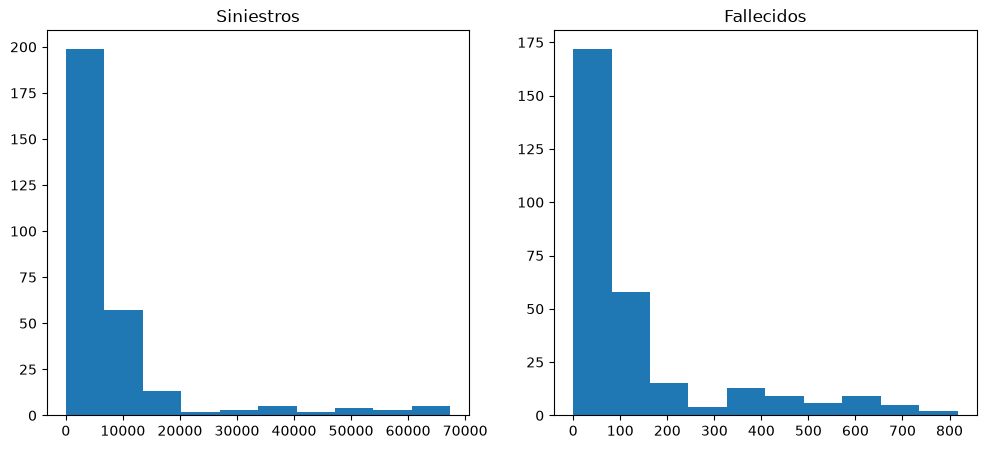

In [97]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].hist(df["Siniestros"])
axes[0].set_title("Siniestros")

axes[1].hist(df["Fallecidos"])
axes[1].set_title("Fallecidos")

plt.show()

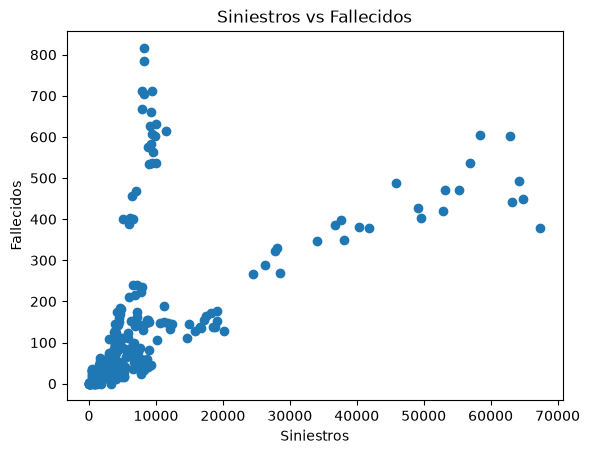

In [103]:
plt.scatter(
    df["Siniestros"],
    df["Fallecidos"]
)

plt.title("Siniestros vs Fallecidos")
plt.xlabel("Siniestros")
plt.ylabel("Fallecidos")

plt.show()


##Interpretacion

Se observa una relacion con una linea de tendencia positiva entre la cantidad de siniestros y el numero de fallecidos.
Sin embargo los datos muestran un grupo que no sigue esta tendencia, lo que sugiere vehiculos que representan un mayor riesgo de fallecimiento.

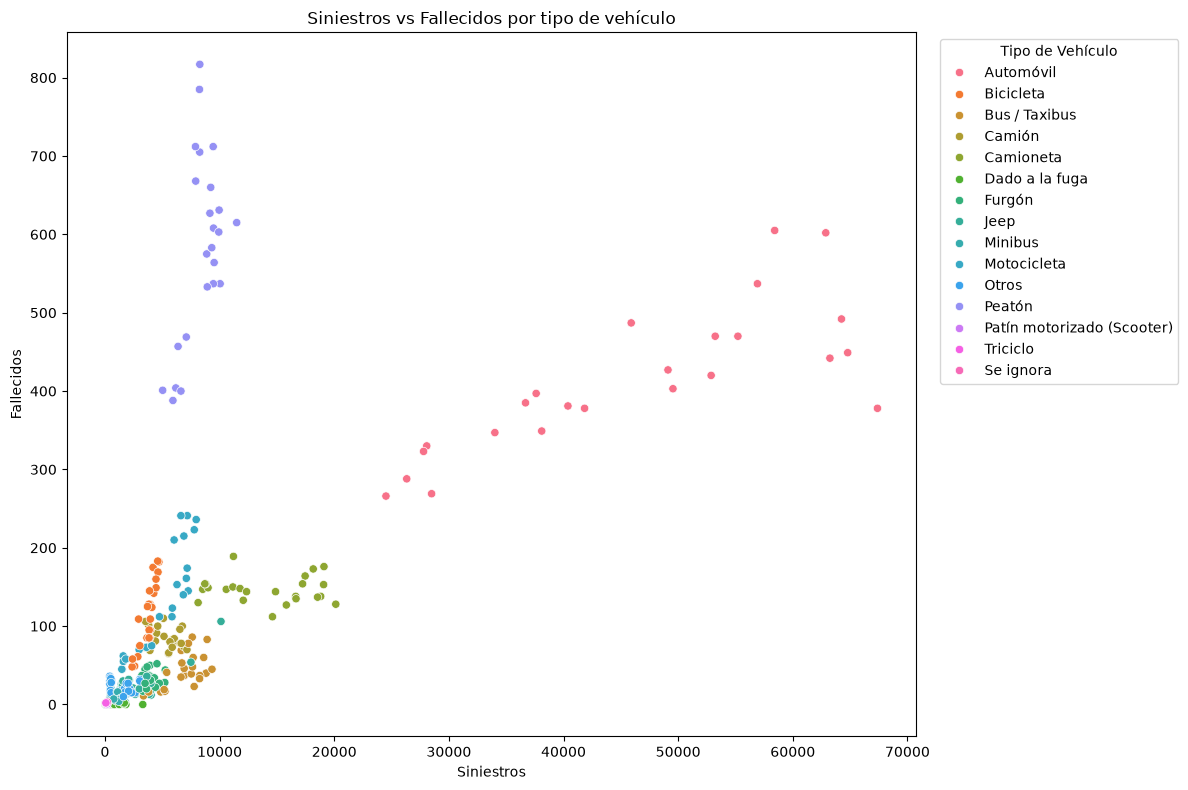

In [119]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    data=df,
    x="Siniestros",
    y="Fallecidos",
    hue="Tipo de Vehículo"
)

plt.title("Siniestros vs Fallecidos por tipo de vehículo")

plt.legend(
    title="Tipo de Vehículo",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()